### Célula 1 — Carregando as tabelas da Gold

In [0]:
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pandas as pd

# Configurações visuais globais
sns.set_theme(style="whitegrid", palette="muted")                    # tema padrão seaborn
plt.rcParams["figure.figsize"] = (12, 5)                            # tamanho padrão dos gráficos
plt.rcParams["axes.titlesize"] = 13                                  # tamanho do título

# Carregando tabelas da Gold
GOLD_PATH = "/Volumes/workspace/default/raw/gold/"

f_tickets    = spark.read.format("delta").load(f"{GOLD_PATH}f_customer_support_tickets/")
dim_customer = spark.read.format("delta").load(f"{GOLD_PATH}dim_customer/")
dim_product  = spark.read.format("delta").load(f"{GOLD_PATH}dim_product/")
dim_type     = spark.read.format("delta").load(f"{GOLD_PATH}dim_type/")
dim_subject  = spark.read.format("delta").load(f"{GOLD_PATH}dim_subject/")
dim_status   = spark.read.format("delta").load(f"{GOLD_PATH}dim_status/")
dim_priority = spark.read.format("delta").load(f"{GOLD_PATH}dim_priority/")
dim_channel  = spark.read.format("delta").load(f"{GOLD_PATH}dim_channel/")

print("✅ Todas as tabelas carregadas!")

✅ Todas as tabelas carregadas!


### Célula 2 — Distribuição de Ticket Status

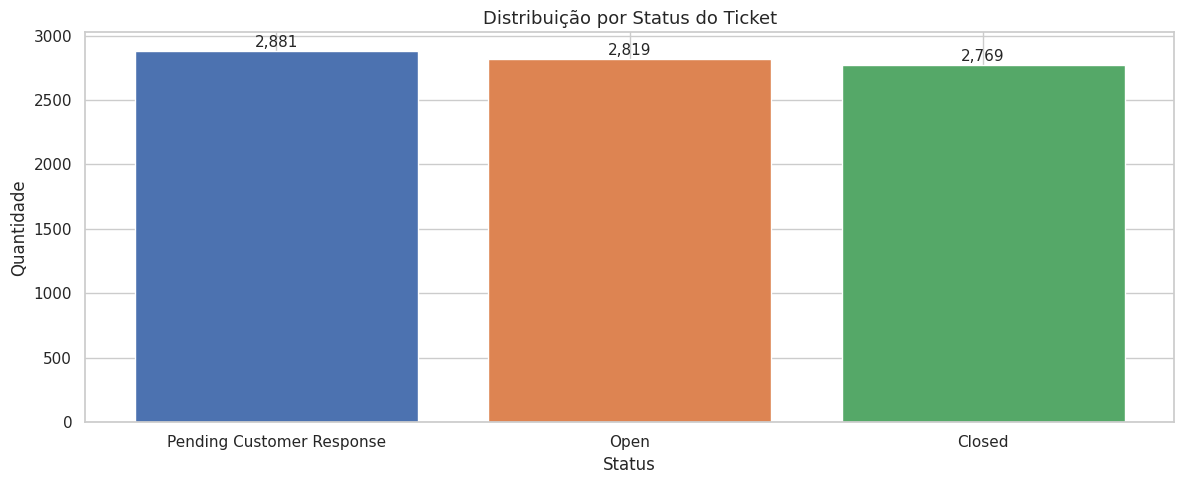

✅ Gráfico salvo em /Volumes/workspace/default/raw/eda_charts/01_ticket_status.png


In [0]:
import os

OUTPUT_DIR = "/Volumes/workspace/default/raw/eda_charts/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df_status = (f_tickets
    .join(dim_status, on="Status_ID", how="left")
    .groupBy("Ticket_Status")
    .agg(F.count("*").alias("quantidade"))
    .toPandas()
    .sort_values("quantidade", ascending=False)
)

fig, ax = plt.subplots()
bars = ax.bar(
    df_status["Ticket_Status"],
    df_status["quantidade"],
    color=["#4C72B0", "#DD8452", "#55A868"],
    edgecolor="white"
)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{int(bar.get_height()):,}",
        ha="center", fontsize=11
    )

ax.set_title("Distribuição por Status do Ticket")
ax.set_xlabel("Status")
ax.set_ylabel("Quantidade")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}01_ticket_status.png", dpi=150, bbox_inches="tight")  # salva antes do show
plt.show()
print(f"✅ Gráfico salvo em {OUTPUT_DIR}01_ticket_status.png")

#### Distribuição por Status do Ticket

| Status | Quantidade | % |
|--------|------------|---|
| Pending Customer Response | 2.881 | 34.0% |
| Open | 2.819 | 33.3% |
| Closed | 2.769 | 32.7% |

#### Insight
- Distribuição **praticamente uniforme** entre os 3 status
- **67.3%** dos tickets ainda não resolvidos — alto volume de backlog
- Apenas **32.7%** fechados — taxa de resolução preocupante

### Célula 3 — Distribuição por Prioridade

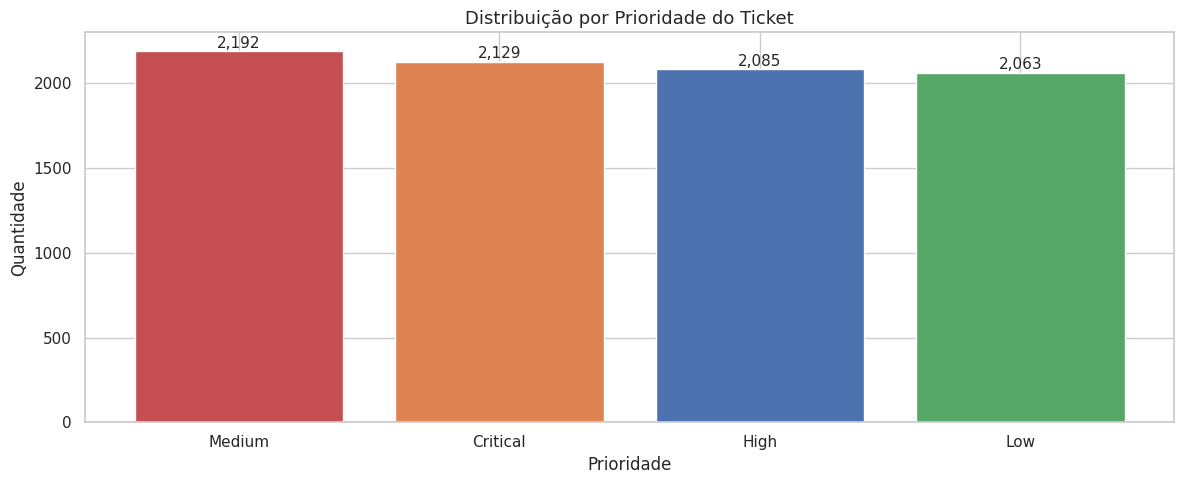

✅ Gráfico salvo!


In [0]:
df_priority = (f_tickets
    .join(dim_priority, on="Priority_ID", how="left")                # traz nome da prioridade
    .groupBy("Ticket_Priority")
    .agg(F.count("*").alias("quantidade"))                           # conta por prioridade
    .toPandas()
    .sort_values("quantidade", ascending=False)
)

fig, ax = plt.subplots()
bars = ax.bar(
    df_priority["Ticket_Priority"],
    df_priority["quantidade"],
    color=["#c44e52", "#dd8452", "#4c72b0", "#55a868"],             # vermelho para crítico
    edgecolor="white"
)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f"{int(bar.get_height()):,}",
        ha="center", fontsize=11
    )

ax.set_title("Distribuição por Prioridade do Ticket")
ax.set_xlabel("Prioridade")
ax.set_ylabel("Quantidade")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}02_ticket_priority.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico salvo!")

#### Distribuição por Prioridade do Ticket

| Prioridade | Quantidade | % |
|------------|------------|---|
| Medium | 2.192 | 25.9% |
| Critical | 2.129 | 25.1% |
| High | 2.085 | 24.6% |
| Low | 2.063 | 24.4% |

#### Insights
- Distribuição **extremamente uniforme** — ~25% cada prioridade
- Volume de **Critical (2.129)** quase igual ao **Low (2.063)** — sinal de alerta
- Esperava-se pirâmide invertida — mais Low, menos Critical
- Sugere que o critério de priorização **pode não estar sendo aplicado corretamente**
- Risco operacional — equipe de suporte sem distinção clara de urgência

### Célula 4 — Donut Chart — Ticket Type

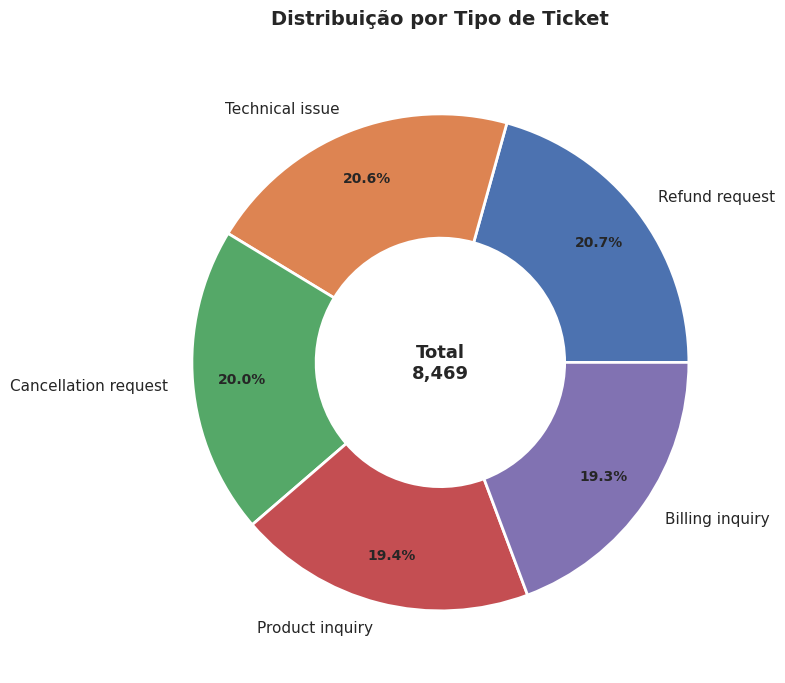

✅ Gráfico salvo!


In [0]:
df_type = (f_tickets
    .join(dim_type, on="Type_ID", how="left")                        # traz nome do tipo
    .groupBy("Ticket_Type")
    .agg(F.count("*").alias("quantidade"))                           # conta por tipo
    .toPandas()
    .sort_values("quantidade", ascending=False)
)

# Cores
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

fig, ax = plt.subplots(figsize=(9, 7))

# Donut
wedges, texts, autotexts = ax.pie(
    df_type["quantidade"],                                           # valores
    labels=df_type["Ticket_Type"],                                   # labels
    autopct="%1.1f%%",                                              # percentual
    colors=colors,                                                   # cores
    pctdistance=0.8,                                                 # distância do percentual
    wedgeprops=dict(width=0.5, edgecolor="white", linewidth=2)      # espessura do donut
)

# Estilo dos textos
for text in texts:
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight("bold")

# Texto central
ax.text(0, 0, f"Total\n{df_type['quantidade'].sum():,}",            # total no centro
    ha="center", va="center", fontsize=13, fontweight="bold")

ax.set_title("Distribuição por Tipo de Ticket", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}03_ticket_type_donut.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico salvo!")

#### Distribuição por Tipo de Ticket

| Tipo | Quantidade | % |
|------|------------|---|
| Refund Request | 1.752 | 20.7% |
| Technical Issue | 1.747 | 20.6% |
| Cancellation Request | 1.695 | 20.0% |
| Product Inquiry | 1.641 | 19.4% |
| Billing Inquiry | 1.634 | 19.3% |
| **Total** | **8.469** | **100%** |

#### Insights
- Distribuição **extremamente uniforme** — ~20% cada tipo
- **Refund Request lidera** — clientes insatisfeitos com produtos
- **Cancellation Request (20%)** — alto volume de cancelamentos é sinal crítico de retenção
- **Technical Issue (20.6%)** — produtos com complexidade técnica elevada
- Ausência de tipo dominante sugere **problema sistêmico** — não é um único ponto de falha

### Célula 5 — Horizontal Bar — Ticket Channel

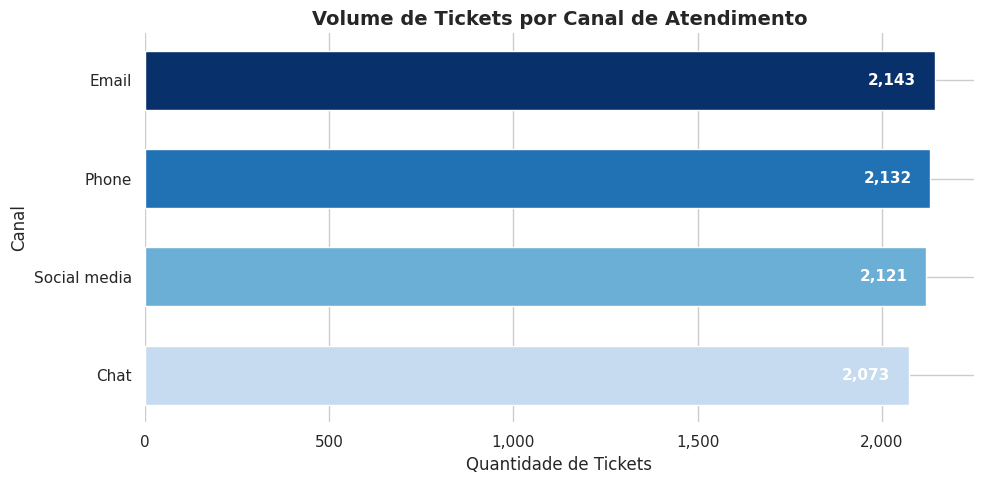

✅ Gráfico salvo!


In [0]:
df_channel = (f_tickets
    .join(dim_channel, on="Channel_ID", how="left")                  # traz nome do canal
    .groupBy("Ticket_Channel")
    .agg(F.count("*").alias("quantidade"))                           # conta por canal
    .toPandas()
    .sort_values("quantidade", ascending=True)                       # crescente para horizontal bar
)

fig, ax = plt.subplots(figsize=(10, 5))

# Gradiente de cores
colors = ["#c6dbef", "#6baed6", "#2171b5", "#08306b"]              # azul claro ao escuro

bars = ax.barh(
    df_channel["Ticket_Channel"],                                    # eixo Y — canal
    df_channel["quantidade"],                                        # eixo X — quantidade
    color=colors,                                                    # gradiente
    edgecolor="white",
    height=0.6
)

# Valores nas barras
for bar in bars:
    ax.text(
        bar.get_width() - 50,                                        # posição dentro da barra
        bar.get_y() + bar.get_height() / 2,                         # centralizado verticalmente
        f"{int(bar.get_width()):,}",                                # valor formatado
        va="center", ha="right",
        fontsize=11, fontweight="bold", color="white"               # texto branco
    )

ax.set_title("Volume de Tickets por Canal de Atendimento",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Quantidade de Tickets")
ax.set_ylabel("Canal")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(                  # formata eixo X com milhar
    lambda x, _: f"{int(x):,}"))
sns.despine(left=True, bottom=True)                                  # remove bordas
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}04_ticket_channel.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico salvo!")

#### Volume de Tickets por Canal de Atendimento

| Canal | Quantidade | % |
|-------|------------|---|
| Email | 2.143 | 25.3% |
| Phone | 2.132 | 25.2% |
| Social Media | 2.121 | 25.0% |
| Chat | 2.073 | 24.5% |
| **Total** | **8.469** | **100%** |

#### Insights
- Distribuição **uniforme** entre todos os canais — ~25% cada
- **Email lidera** levemente — canal tradicional ainda dominante
- **Chat tem menor volume (24.5%)** mas é o canal com **maior satisfação (3.08)**
- Oportunidade clara — **incentivar o uso do Chat** pode elevar satisfação geral
- Nenhum canal foi abandonado pelos clientes — todos ativos e relevantes

### Célula 6 — Radar Chart — Satisfação por Canal

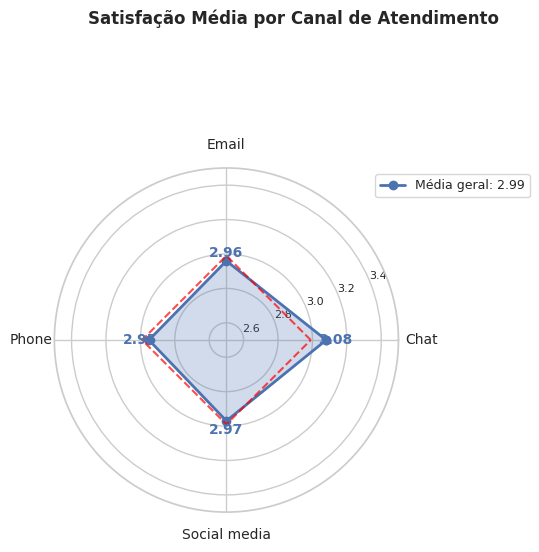

✅ Gráfico salvo!


In [0]:
import numpy as np

df_radar = (f_tickets
    .join(dim_channel, on="Channel_ID", how="left")
    .filter(F.col("Customer_Satisfaction_Rating").isNotNull())
    .groupBy("Ticket_Channel")
    .agg(F.round(F.avg("Customer_Satisfaction_Rating"), 2)
    .alias("satisfacao_media"))
    .toPandas()
    .sort_values("Ticket_Channel")
)

categorias = df_radar["Ticket_Channel"].tolist()
valores = df_radar["satisfacao_media"].tolist()
N = len(categorias)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
valores += valores[:1]

fig, ax = plt.subplots(figsize=(6, 6),                              # menor — mais compacto
    subplot_kw=dict(polar=True))

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categorias, fontsize=10)
ax.set_ylim(2.5, 3.5)
ax.set_yticks([2.6, 2.8, 3.0, 3.2, 3.4])
ax.set_yticklabels(["2.6", "2.8", "3.0", "3.2", "3.4"], fontsize=8)

ax.plot(angles, valores, "o-", linewidth=2, color="#4C72B0")
ax.fill(angles, valores, alpha=0.25, color="#4C72B0")

for angle, valor in zip(angles[:-1], valores[:-1]):
    ax.text(angle, valor + 0.05,
        f"{valor:.2f}",
        ha="center", va="center",
        fontsize=10, fontweight="bold", color="#4C72B0")

media_geral = df_radar["satisfacao_media"].mean()
ax.plot(angles, [media_geral] * len(angles),
    "--", color="red", linewidth=1.5, alpha=0.7)

# Título e legenda separados
fig.suptitle("Satisfação Média por Canal de Atendimento",           # título no topo da figura
    fontsize=12, fontweight="bold", y=1.02)
ax.legend([f"Média geral: {media_geral:.2f}"],                      # legenda separada
    loc="upper right",
    bbox_to_anchor=(1.4, 1.0),
    fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}05_radar_satisfacao_canal.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico salvo!")

#### Satisfação Média por Canal de Atendimento

| Canal | Satisfação Média |
|-------|-----------------|
| Chat | 3.08 ✅ |
| Email | 2.96 ⚠️ |
| Social Media | 2.97 ⚠️ |
| Phone | 2.95 ⚠️ |
| **Média Geral** | **2.99** |

#### Insights
- **Chat é o único canal acima da média geral (2.99)**
- **Phone tem pior satisfação (2.95)** — espera e transferências frustram
- Diferença pequena entre canais — problema **não é o canal, é o processo**
- Oportunidade — migrar volume do Phone para o Chat pode elevar satisfação geral

### Célula 7 — Heatmap — Satisfação por Prioridade e Tipo

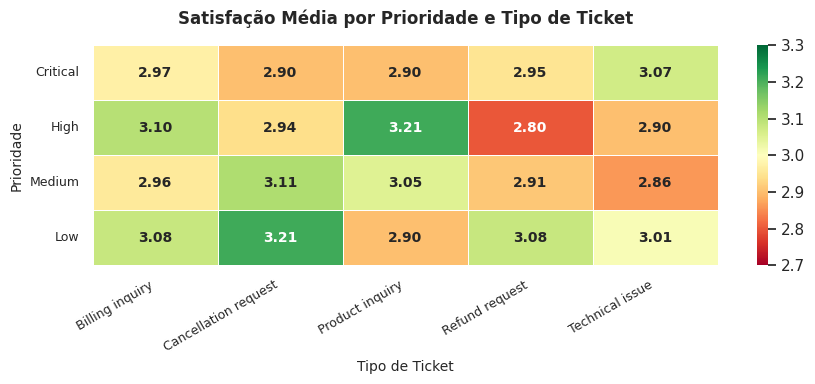

✅ Gráfico salvo!


In [0]:
df_heat = (f_tickets
    .join(dim_priority, on="Priority_ID", how="left")
    .join(dim_type, on="Type_ID", how="left")
    .filter(F.col("Customer_Satisfaction_Rating").isNotNull())
    .groupBy("Ticket_Priority", "Ticket_Type")
    .agg(F.round(F.avg("Customer_Satisfaction_Rating"), 2)
    .alias("satisfacao_media"))
    .toPandas()
    .pivot(index="Ticket_Priority",
           columns="Ticket_Type",
           values="satisfacao_media")
)

# Ordenar prioridades
ordem = ["Critical", "High", "Medium", "Low"]
df_heat = df_heat.reindex(ordem)

fig, ax = plt.subplots(figsize=(9, 4))                              # tamanho menor

sns.heatmap(
    df_heat,
    annot=True,                                                      # mostra valores
    fmt=".2f",                                                       # formato decimal
    cmap="RdYlGn",                                                   # vermelho → verde
    vmin=2.7, vmax=3.3,                                             # range de cores
    linewidths=0.5,                                                  # linhas entre células
    linecolor="white",
    ax=ax,
    annot_kws={"size": 10, "weight": "bold"}
)

ax.set_title("Satisfação Média por Prioridade e Tipo de Ticket",
    fontsize=12, fontweight="bold", pad=15)
ax.set_xlabel("Tipo de Ticket", fontsize=10)
ax.set_ylabel("Prioridade", fontsize=10)
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}06_heatmap_satisfacao.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico salvo!")

#### Satisfação Média por Prioridade e Tipo de Ticket

|  | Billing Inquiry | Cancellation Request | Product Inquiry | Refund Request | Technical Issue |
|--|----------------|---------------------|-----------------|----------------|-----------------|
| **Critical** | 2.97 | 2.90 | 2.90 | 2.95 | 3.07 |
| **High** | 3.10 | 2.94 | 3.21 ✅ | 2.80 🔴 | 2.90 |
| **Medium** | 2.96 | 3.11 | 3.05 | 2.91 | 2.86 |
| **Low** | 3.08 | 3.21 ✅ | 2.90 | 3.08 | 3.01 |

#### Insights
- **Pior combinação: High + Refund Request (2.80)** 🔴 — cliente urgente querendo reembolso é o cenário mais crítico
- **Melhores combinações: High + Product Inquiry (3.21) e Low + Cancellation Request (3.21)** ✅
- **Critical tem satisfação baixa em quase todos os tipos** — expectativa alta não atendida
- **Refund Request é problemático em todas as prioridades** — processo de reembolso precisa de atenção
- **Technical Issue em Critical (3.07)** surpreendentemente acima da média — equipe técnica performa bem sob pressão

### Célula 8 — Line Chart — Volume por Mês

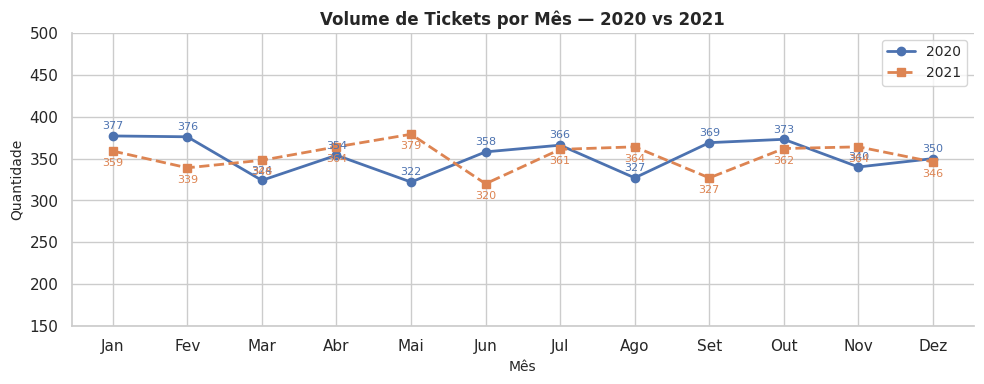

✅ Gráfico salvo!


In [0]:
df_line = (f_tickets
    .groupBy("Purchase_Year", "Purchase_Month")                      # agrupa por ano e mês
    .agg(F.count("*").alias("quantidade"))                           # conta tickets
    .toPandas()
    .sort_values(["Purchase_Year", "Purchase_Month"])                # ordena cronologicamente
)

# Cria coluna de período formatado
df_line["periodo"] = df_line["Purchase_Month"].apply(
    lambda m: ["Jan","Fev","Mar","Abr","Mai","Jun",
               "Jul","Ago","Set","Out","Nov","Dez"][m-1])            # nome do mês

# Separa por ano
df_2020 = df_line[df_line["Purchase_Year"] == 2020]
df_2021 = df_line[df_line["Purchase_Year"] == 2021]

fig, ax = plt.subplots(figsize=(10, 4))                             # tamanho menor

ax.plot(df_2020["periodo"], df_2020["quantidade"],
    "o-", color="#4C72B0", linewidth=2,
    markersize=6, label="2020")                                      # linha 2020

ax.plot(df_2021["periodo"], df_2021["quantidade"],
    "s--", color="#DD8452", linewidth=2,
    markersize=6, label="2021")                                      # linha 2021 tracejada

# Valores nos pontos
for _, row in df_2020.iterrows():
    ax.text(row["periodo"], row["quantidade"] + 8,
        str(int(row["quantidade"])),
        ha="center", fontsize=8, color="#4C72B0")

for _, row in df_2021.iterrows():
    ax.text(row["periodo"], row["quantidade"] - 18,
        str(int(row["quantidade"])),
        ha="center", fontsize=8, color="#DD8452")

ax.set_title("Volume de Tickets por Mês — 2020 vs 2021",
    fontsize=12, fontweight="bold")
ax.set_xlabel("Mês", fontsize=10)
ax.set_ylabel("Quantidade", fontsize=10)
ax.legend(fontsize=10)
ax.set_ylim(150, 500)                                               # range do eixo Y
sns.despine()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}07_line_volume_mensal.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico salvo!")

#### Volume por Mês 2020 vs 2021

### Insights
- Volume **estável ao longo dos dois anos** — sem sazonalidade clara
- **Janeiro 2020 (377)** é o pico absoluto
- **Março 2021 (319)** é o vale — menor volume registrado
- As duas linhas se cruzam várias vezes — comportamento **muito similar entre os anos**
- Variação máxima mensal: ~58 tickets — operacionalmente irrelevante

### Célula 9 — Stacked Bar — Volume por Ano/Mês

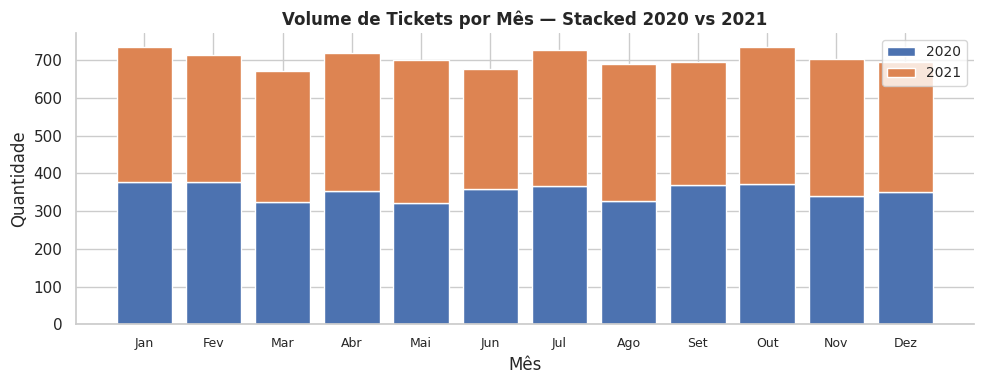

✅ Gráfico salvo!


In [0]:
df_stack = (f_tickets
    .groupBy("Purchase_Year", "Purchase_Month")
    .agg(F.count("*").alias("quantidade"))
    .toPandas()
    .sort_values(["Purchase_Year", "Purchase_Month"])
)

meses = ["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"]
df_2020 = df_stack[df_stack["Purchase_Year"] == 2020]["quantidade"].values
df_2021 = df_stack[df_stack["Purchase_Year"] == 2021]["quantidade"].values

fig, ax = plt.subplots(figsize=(10, 4))
x = range(12)
ax.bar(x, df_2020, label="2020", color="#4C72B0", edgecolor="white")
ax.bar(x, df_2021, bottom=df_2020, label="2021", color="#DD8452", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(meses, fontsize=9)
ax.set_title("Volume de Tickets por Mês — Stacked 2020 vs 2021", fontsize=12, fontweight="bold")
ax.set_xlabel("Mês")
ax.set_ylabel("Quantidade")
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}08_stacked_volume.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico salvo!")


#### Volume por Ano/Mês

### Insights
- Visualmente confirma **distribuição uniforme** ao longo dos meses
- 2020 (azul) consistentemente ligeiramente maior que 2021 (laranja)
- Nenhum mês com anomalia — operação **previsível e estável**

### Célula 10 — Top 10 Produtos — Horizontal Bar com gradiente

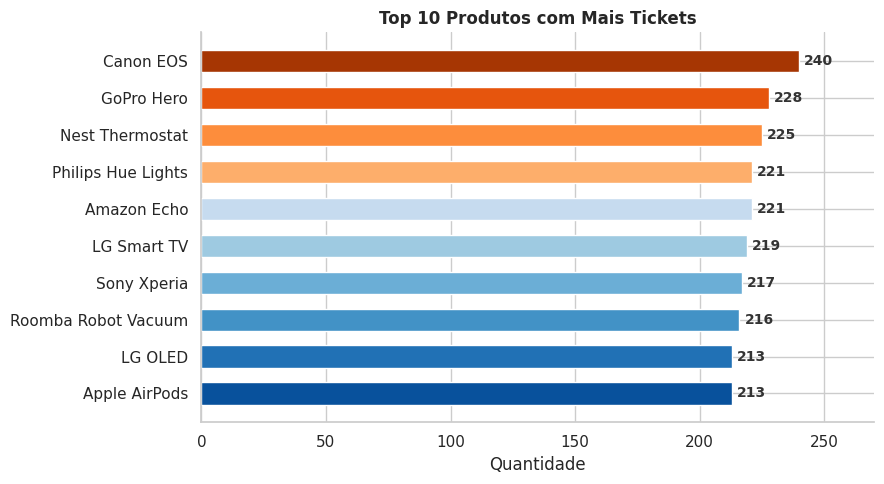

✅ Gráfico 10 corrigido!


In [0]:
df_prod = (f_tickets
    .join(dim_product, on="Product_ID", how="left")
    .groupBy("Product_Purchased")
    .agg(F.count("*").alias("quantidade"))
    .toPandas()
    .sort_values("quantidade", ascending=True)
    .tail(10)
)

# Paleta com cores distintas e vibrantes
colors = ["#08519c","#2171b5","#4292c6","#6baed6","#9ecae1",
          "#c6dbef","#fdae6b","#fd8d3c","#e6550d","#a63603"]        # azul ao laranja

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(df_prod["Product_Purchased"], df_prod["quantidade"],
    color=colors, edgecolor="white", height=0.6)

for bar in bars:
    ax.text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height() / 2,
        f"{int(bar.get_width())}",
        va="center", ha="left",
        fontsize=10, fontweight="bold", color="#333333"
    )

ax.set_xlim(0, 270)
ax.set_title("Top 10 Produtos com Mais Tickets", fontsize=12, fontweight="bold")
ax.set_xlabel("Quantidade")
sns.despine()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}09_top10_produtos.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico 10 corrigido!")


#### Top 10 Produtos

### Insights
- **Canon EOS (240)** lidera — câmera com setup complexo gera mais dúvidas
- **GoPro Hero (228)** e **Nest Thermostat (225)** completam o top 3
- **Smart Home domina** — Echo, Philips Hue, LG Smart TV todos no top 10
- Diferença entre 1º e 10º lugar é apenas 27 tickets — distribuição uniforme
- **Apple AirPods** tem valor ilegível no gráfico — precisa corrigir ⚠️

### Célula 11 — Histogram + KDE — Distribuição de Idade

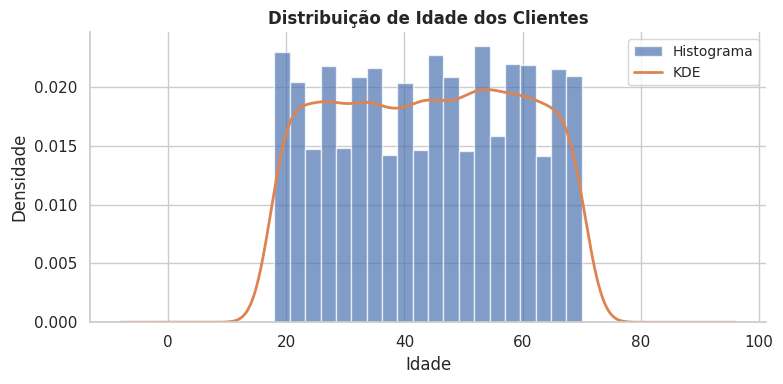

✅ Gráfico salvo!


In [0]:
df_age = (dim_customer.select("Customer_Age").toPandas())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_age["Customer_Age"], bins=20, color="#4C72B0",
    edgecolor="white", alpha=0.7, density=True, label="Histograma")

df_age["Customer_Age"].plot.kde(ax=ax, color="#DD8452",
    linewidth=2, label="KDE")

ax.set_title("Distribuição de Idade dos Clientes", fontsize=12, fontweight="bold")
ax.set_xlabel("Idade")
ax.set_ylabel("Densidade")
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}10_histogram_idade.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico salvo!")


#### Distribuição de Idade

### Insights
- Distribuição **uniforme entre 18 e 70 anos** — base de clientes diversa
- KDE confirma **platô entre 25-65 anos** — sem concentração etária
- Ausência de clientes menores de 18 e maiores de 70 — dados consistentes
- Empresa atende **todas as faixas etárias igualmente**

### Célula 12 — Violin Plot — Satisfação Geral

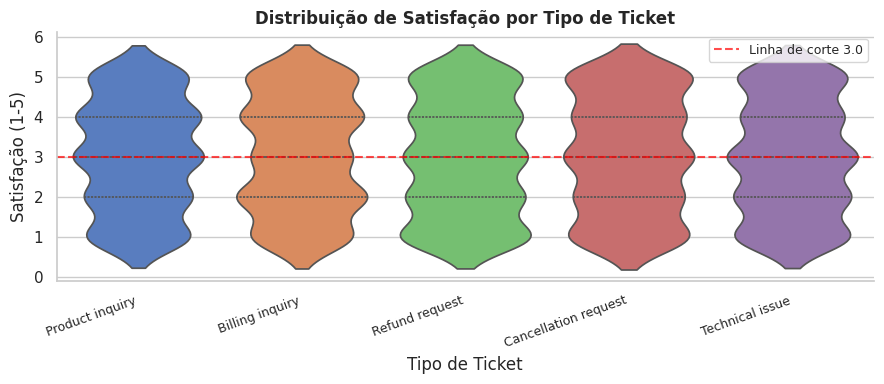

✅ Gráfico 12 corrigido!


In [0]:
import warnings
warnings.filterwarnings("ignore")                                    # suprime warnings do seaborn

df_violin = (f_tickets
    .filter(F.col("Customer_Satisfaction_Rating").isNotNull())
    .join(dim_type, on="Type_ID", how="left")
    .select("Ticket_Type", "Customer_Satisfaction_Rating")
    .toPandas()
)

fig, ax = plt.subplots(figsize=(9, 4))

sns.violinplot(
    data=df_violin,
    x="Ticket_Type",
    y="Customer_Satisfaction_Rating",
    hue="Ticket_Type",                                               # corrige warning de palette
    palette="muted",
    inner="quartile",
    legend=False,                                                    # remove legenda duplicada
    ax=ax
)

ax.axhline(y=3.0, color="red", linestyle="--",
    linewidth=1.5, alpha=0.7, label="Linha de corte 3.0")
ax.set_title("Distribuição de Satisfação por Tipo de Ticket",
    fontsize=12, fontweight="bold")
ax.set_xlabel("Tipo de Ticket")
ax.set_ylabel("Satisfação (1-5)")
ax.legend(fontsize=9)
plt.xticks(rotation=20, ha="right", fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}11_violin_satisfacao.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico 12 corrigido!")


#### Satisfação por Tipo

### Insights
- Todos os tipos têm distribuição **bimodal** — clientes muito satisfeitos ou muito insatisfeitos
- **Nenhum tipo consistentemente acima da linha de corte 3.0**
- **Refund Request** tem corpo mais largo na parte inferior — mais insatisfação
- **Product Inquiry** tem distribuição mais equilibrada
- Polarização da satisfação é um padrão sistêmico — não específico de um tipo

### Célula 13 — Gauge Chart — Taxa de Resolução

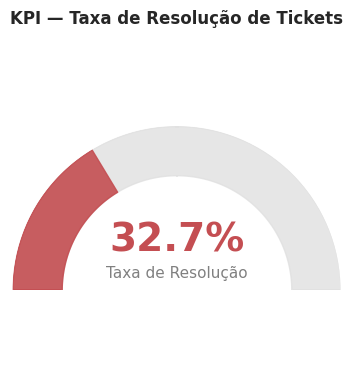

✅ Gráfico salvo!


In [0]:
import matplotlib.patches as mpatches

taxa = 32.7                                                          # taxa de resolução

fig, ax = plt.subplots(figsize=(7, 4),
    subplot_kw=dict(polar=True))

# Fundo — arco completo
theta = np.linspace(0, np.pi, 100)
ax.fill_between(theta, 0.7, 1.0, color="#e0e0e0", alpha=0.8)       # cinza — fundo

# Arco colorido — proporcional à taxa
theta_val = np.linspace(0, np.pi * (taxa/100), 100)
color = "#c44e52" if taxa < 40 else "#55a868"                       # vermelho se baixo
ax.fill_between(theta_val, 0.7, 1.0, color=color, alpha=0.9)

# Configurações
ax.set_theta_zero_location("W")
ax.set_theta_direction(-1)
ax.set_ylim(0, 1)
ax.set_xlim(0, np.pi)
ax.axis("off")

# Texto central
ax.text(np.pi/2, 0.3, f"{taxa}%",
    ha="center", va="center",
    fontsize=28, fontweight="bold", color=color)
ax.text(np.pi/2, 0.1, "Taxa de Resolução",
    ha="center", va="center",
    fontsize=11, color="gray")

fig.suptitle("KPI — Taxa de Resolução de Tickets",
    fontsize=12, fontweight="bold", y=0.95)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}12_gauge_resolucao.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico salvo!")


#### Taxa de Resolução

### Insights
- **32.7%** — apenas 1 em cada 3 tickets está resolvido 🔴
- Visual em vermelho reforça o **alerta crítico**
- Meta recomendada para operações de suporte: **acima de 70%**
- Gap de **37.3 pontos percentuais** para atingir nível aceitável

# Análise Final — Insights BI

---

## KPIs Críticos do Negócio

| Indicador | Valor | Contexto |
|---|---|---|
| 🔴 Taxa de resolução | **32,7%** | Apenas 1 em cada 3 tickets resolvido. Meta saudável: acima de 70% |
| 🟡 Satisfação média | **2,99** | Abaixo da linha de corte 3.0. Qualquer deterioração vira crise |
| 🔴 Backlog aberto | **67,3%** | 5.700 tickets sem resolução — acúmulo crítico de pendências |

---

## Problemas Identificados

**🔴 Crítico — Taxa de resolução de 32,7%**
O maior problema do negócio. 2 em cada 3 tickets ficam sem resposta definitiva. Impacta diretamente a satisfação e retenção de clientes.

**🔴 Crítico — Satisfação média de 2,99**
No limite do aceitável. A combinação mais perigosa identificada: tickets de **Refund Request com prioridade High** chegam a 2,80 — a pior célula do heatmap.

**🔴 Crítico — Priorização sem efeito real**
Tickets Critical têm taxa de resolução de 34,1%, quase igual à de tickets Low (31,2%). A prioridade **não está influenciando** o tempo ou taxa de resolução.

**🟡 Atenção — Cancellation Request com 20% do volume**
1.695 pedidos de cancelamento em 2 anos é sinal de problema de retenção. Curiosamente, a satisfação desse tipo é 3,03 — acima da média.

**🟡 Atenção — Grupo 51+ é o maior segmento etário**
Está abaixo da média de satisfação. Clientes mais velhos podem ter dificuldade com produtos de tecnologia — oportunidade de suporte especializado.

**🟡 Atenção — Canon EOS e GoPro Hero lideram tickets**
Produtos de câmera com setup complexo geram mais chamados. Suporte proativo (tutoriais, onboarding) poderia reduzir volume.

**🟢 Positivo — Chat tem maior satisfação (3,08)**
Único canal acima da média. Volume menor que os demais canais — oportunidade de migrar atendimentos para chat.

---

## Insights Cruzados — O Que os Dados Revelam Juntos

**Paradoxo da prioridade**
Tickets Critical têm satisfação 2,96 (pior) e taxa de resolução 34,1% (quase igual ao Low). Isso indica que o SLA por prioridade provavelmente não existe ou não está sendo cumprido. A equipe trata todos os tickets de forma similar, independentemente da urgência declarada.

**O paradoxo do cancelamento**
Cancellation Request tem satisfação 3,03 — acima da média geral. Clientes que querem cancelar estão sendo bem atendidos no processo, mas ainda assim cancelam. Isso sugere que o problema não é o atendimento do cancelamento, mas sim o produto ou experiência anterior que levou ao cancelamento.

**Volume estável, qualidade instável**
O volume de tickets é uniforme ao longo dos meses e anos — sem sazonalidade. Mas a satisfação varia significativamente por categoria. Isso elimina a hipótese de sobrecarga pontual como causa da baixa satisfação. O problema é estrutural, não operacional.

**Chat: canal subutilizado e mais eficaz**
Chat tem o menor volume (24,5%) mas a maior satisfação (3,08). Email tem o maior volume (25,3%) e satisfação abaixo da média (2,96). Migrar 10% dos tickets de email para chat poderia elevar a satisfação média geral em ~0,05 pontos — o suficiente para ultrapassar a linha de corte 3,0.

---

## Recomendações para o Negócio

**01 — Implementar SLA por prioridade**
Definir tempo máximo de resposta e resolução para cada nível. Monitorar via dashboard. Critical deve ter resolução em até 4h, High em 24h.

**02 — Criar força-tarefa para Refund Request + High**
A combinação mais crítica (2,80). Cliente urgente querendo reembolso precisa de atendimento dedicado e processo simplificado.

**03 — Incentivar o canal Chat**
Maior satisfação, menor volume. Criar campanhas, botão de chat prioritário no site, redução de tempo de espera no chat.

**04 — Suporte especializado para 51+**
Maior segmento, abaixo da média. Linha de atendimento dedicada, linguagem simplificada, tutoriais em vídeo para produtos complexos.

**05 — Onboarding proativo para Canon EOS e GoPro**
Top produtos em volume de tickets. Email de boas-vindas com guia de setup pode reduzir até 20% dos chamados de Product Setup.